<a href="https://colab.research.google.com/github/kasivaaa/advancedML_week3_project/blob/main/Air_Quality_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Forecasting in Beijing

In [ ]:
import warnings, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "axes.titleweight": "bold"})



In [4]:
from pathlib import Path
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

### Load dataset

The data are the hourly records of **12 national air-quality monitoring stations in Beijing** (Aotizhongxin, Changping, Dingling, Dongsi, Guanyuan, Gucheng, Huairou, Nongzhanguan, Shunyi, Tiantan, Wanliu, Wanshouxigong). *(The assignment text says "12 cities", but they are 12 stations in the Beijing municipality.)* Each station has

* **pollutants:** PM2.5, PM10, SO2, NO2, CO, O3 (µg/m³; CO in µg/m³ as well in this file),
* **meteorology** from the nearest weather station: TEMP (°C), PRES (hPa), DEWP (dew-point °C), RAIN (mm), wd (wind direction, 16 compass points), WSPM (wind speed, m/s).



In [5]:
GITHUB_ZIP = ("https://raw.githubusercontent.com/Afkerian/Beijing-Multi-Site-Air-Quality-Data-Data-Set/"
              "main/data/beijing%2Bmulti%2Bsite%2Bair%2Bquality%2Bdata/PRSA2017_Data_20130301-20170228.zip")
UCI_ZIP = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"


def station_files():
    return sorted(DATA_DIR.rglob("PRSA_Data_*.csv"))


def download_and_extract(url):
    """Download a zip into DATA_DIR and extract it (also extracts zips nested inside)."""
    target = DATA_DIR / "download.zip"
    urllib.request.urlretrieve(url, target)
    with zipfile.ZipFile(target) as z:
        z.extractall(DATA_DIR)
    for inner in list(DATA_DIR.rglob("*.zip")):          # UCI wraps the data in a second zip
        if inner != target:
            with zipfile.ZipFile(inner) as z:
                z.extractall(DATA_DIR)
    target.unlink()


def load_raw():
    if not station_files():
        for url in (GITHUB_ZIP, UCI_ZIP):
            try:
                print("Downloading", url)
                download_and_extract(url)
                if station_files():
                    break
            except Exception as e:                       # network / 403 -> try next source
                print("  failed:", e)
    if station_files():
        return pd.concat([pd.read_csv(f) for f in station_files()], ignore_index=True)

    # last resort: OpenML (dataset id 42933) -- column names are normalised below
    from sklearn.datasets import fetch_openml
    print("Falling back to OpenML 42933")
    return fetch_openml(data_id=42933, as_frame=True, parser="auto").frame


raw = load_raw()
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns from {raw['station'].nunique()} stations")
raw.head()

Loaded 420,768 rows x 18 columns from 12 stations


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [6]:
raw = raw.rename(columns={"PM2.5": "PM25"})
raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw = raw.drop(columns=["No"], errors="ignore").sort_values(["station", "datetime"]).reset_index(drop=True)

POLLUTANTS = ["PM25", "PM10", "SO2", "NO2", "CO", "O3"]
METEO = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

# structural checks: one row per station-hour, complete hourly grid?
expected_hours = pd.date_range("2013-03-01 00:00", "2017-02-28 23:00", freq="h").size
check = raw.groupby("station").agg(rows=("datetime", "size"), first=("datetime", "min"),
                                   last=("datetime", "max"), duplicates=("datetime", lambda s: s.duplicated().sum()))
check["complete_grid"] = check["rows"] == expected_hours
display(check)

,rows,first,last,duplicates,complete_grid
station,,,,,
Aotizhongxin,35064,2013-03-01,2017-02-28 23:00:00,0,True
Changping,35064,2013-03-01,2017-02-28 23:00:00,0,True
Dingling,35064,2013-03-01,2017-02-28 23:00:00,0,True
Dongsi,35064,2013-03-01,2017-02-28 23:00:00,0,True
Guanyuan,35064,2013-03-01,2017-02-28 23:00:00,0,True
Gucheng,35064,2013-03-01,2017-02-28 23:00:00,0,True
Huairou,35064,2013-03-01,2017-02-28 23:00:00,0,True
Nongzhanguan,35064,2013-03-01,2017-02-28 23:00:00,0,True
Shunyi,35064,2013-03-01,2017-02-28 23:00:00,0,True


Every station has the full hourly grid (35 064 hours = 1 461 days) and no duplicates, so no re-indexing is required. The remaining quality problems are **missing values and implausible readings**, examined next.

### Exploratory data analysis

In [7]:
num_cols = POLLUTANTS + METEO
summary = raw[num_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary["missing_%"] = (raw[num_cols].isna().mean() * 100).round(2)
display(summary.round(2))

,count,mean,std,min,50%,max,missing_%
PM25,412029.0,79.79,80.82,2.00,55.0,999.0,2.08
PM10,414319.0,104.60,91.77,2.00,82.0,999.0,1.53
SO2,411747.0,15.83,21.65,0.29,7.0,500.0,2.14
NO2,408652.0,50.64,35.13,1.03,43.0,290.0,2.88
CO,400067.0,1230.77,1160.18,100.00,900.0,10000.0,4.92
O3,407491.0,57.37,56.66,0.21,45.0,1071.0,3.16
TEMP,420370.0,13.54,11.44,-19.90,14.5,41.6,0.09
PRES,420375.0,1010.75,10.47,982.40,1010.4,1042.8,0.09
DEWP,420365.0,2.49,13.79,-43.40,3.1,29.1,0.10
RAIN,420378.0,0.06,0.82,0.00,0.0,72.5,0.09


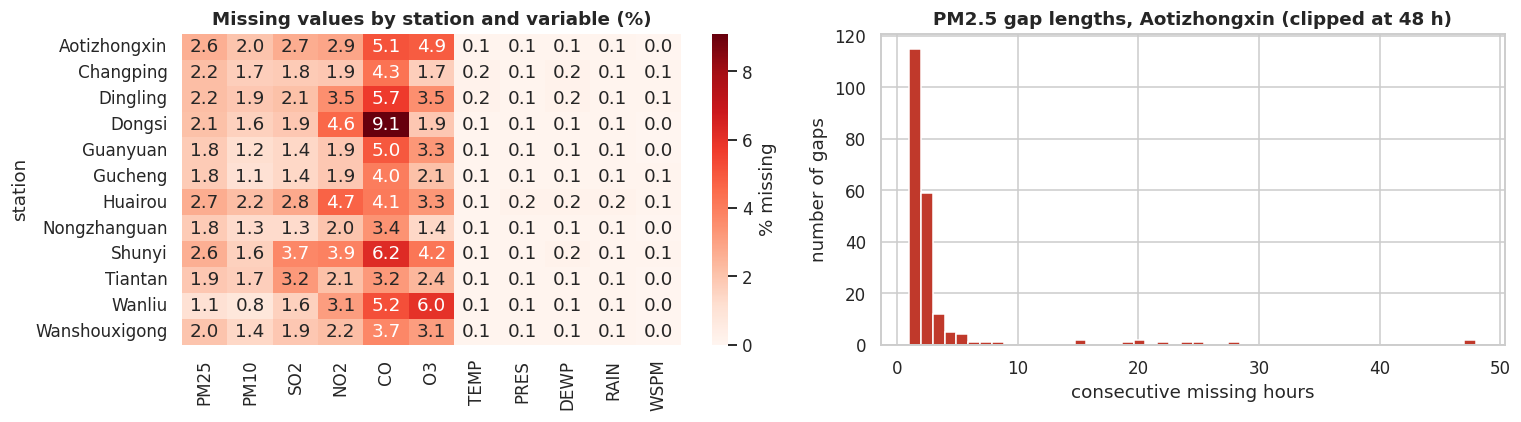

Gaps of <= 6 h: 94%   |   gaps > 24 h: 4


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss = raw.groupby("station")[POLLUTANTS + METEO].apply(lambda d: d.isna().mean() * 100)
sns.heatmap(miss.round(1), annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% missing"}, ax=axes[0])
axes[0].set_title("Missing values by station and variable (%)")

# length of gaps in PM2.5 (consecutive missing hours) for one station: are the gaps short or long?
s = raw.loc[raw.station == "Aotizhongxin", "PM25"]
run_id = (s.notna()).cumsum()
gap_len = s.isna().groupby(run_id).sum()
gap_len = gap_len[gap_len > 0]
axes[1].hist(gap_len.clip(upper=48), bins=48, color="#c0392b")
axes[1].set_title("PM2.5 gap lengths, Aotizhongxin (clipped at 48 h)")
axes[1].set_xlabel("consecutive missing hours"); axes[1].set_ylabel("number of gaps")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_missing_values.png", bbox_inches="tight"); plt.show()
print(f"Gaps of <= 6 h: {(gap_len <= 6).mean():.0%}   |   gaps > 24 h: {(gap_len > 24).sum()}")

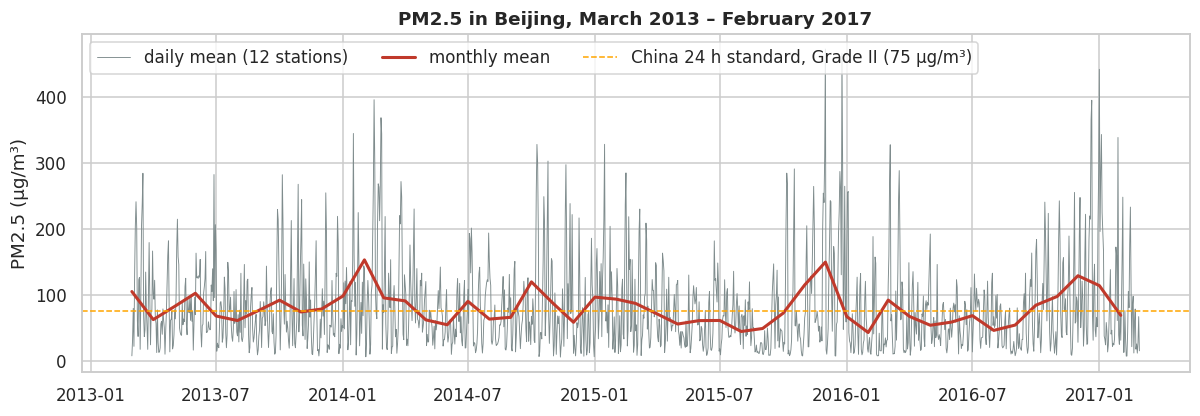

In [9]:
# Raw look at the whole record: daily PM2.5 averaged over the 12 stations, with monthly mean overlaid
tmp = raw.groupby(raw.datetime.dt.floor("D"))["PM25"].mean()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tmp.index, tmp, lw=0.6, color="#7f8c8d", label="daily mean (12 stations)")
ax.plot(tmp.resample("MS").mean().index, tmp.resample("MS").mean(), color="#c0392b", lw=2, label="monthly mean")
ax.axhline(75, color="orange", ls="--", lw=1, label="China 24 h standard, Grade II (75 µg/m³)")
ax.set_ylabel("PM2.5 (µg/m³)"); ax.set_title("PM2.5 in Beijing, March 2013 – February 2017"); ax.legend(ncol=3)
plt.savefig(OUT_DIR / "02_pm25_overview.png", bbox_inches="tight"); plt.show()

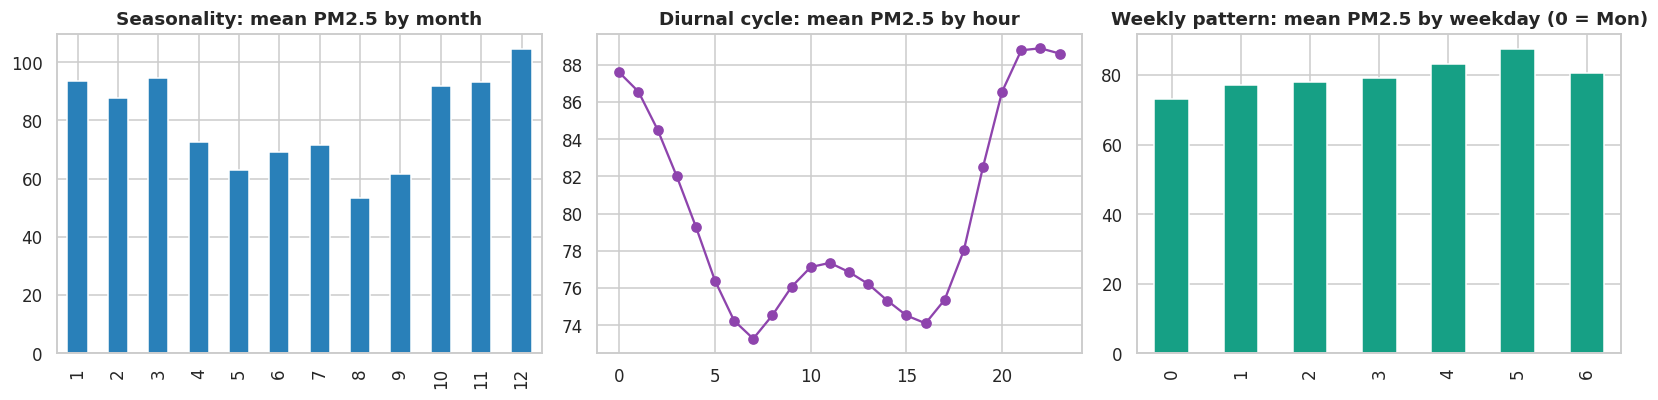

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
pm = raw[["datetime", "PM25"]].dropna().copy()
pm["month"], pm["hour"], pm["dow"] = pm.datetime.dt.month, pm.datetime.dt.hour, pm.datetime.dt.dayofweek

pm.groupby("month")["PM25"].mean().plot.bar(ax=axes[0], color="#2980b9"); axes[0].set_title("Seasonality: mean PM2.5 by month")
pm.groupby("hour")["PM25"].mean().plot(ax=axes[1], marker="o", color="#8e44ad"); axes[1].set_title("Diurnal cycle: mean PM2.5 by hour")
pm.groupby("dow")["PM25"].mean().plot.bar(ax=axes[2], color="#16a085"); axes[2].set_title("Weekly pattern: mean PM2.5 by weekday (0 = Mon)")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "03_seasonality.png", bbox_inches="tight"); plt.show()

**Findings.**
* A clear **annual cycle**: highest in the heating/winter half-year (Oct – Mar, peak in December), lowest in summer (Aug is the minimum: rain, stronger convection). SARIMA with a 365-day period is impractical, so annual seasonality is handled with **Fourier terms** (dynamic harmonic regression) and calendar features.
* The **diurnal cycle** is modest (≈ 73 – 89 µg/m³; evening/night maximum, mid-morning and late-afternoon minimum) and vanishes once we move to daily means.
* The **weekly pattern is weak**: a mild drift upwards from Monday (lowest) to Saturday (highest), far smaller than the seasonal swing. Weekday features are cheap, so they are included, but little is expected from them.

### Data preprocessing




In [11]:
df = raw.copy()
report = {}

# 3.1 physical plausibility ------------------------------------------------------------
limits = {"PM25": (0, 1000), "PM10": (0, 1000), "SO2": (0, 1000), "NO2": (0, 1000), "CO": (0, 20000), "O3": (0, 1000),
          "TEMP": (-40, 45), "PRES": (900, 1100), "DEWP": (-60, 40), "RAIN": (0, 200), "WSPM": (0, 40)}
for c, (lo, hi) in limits.items():
    bad = (df[c] < lo) | (df[c] > hi)
    report[c] = {"implausible": int(bad.sum())}
    df.loc[bad, c] = np.nan
# PM2.5 is a subset of PM10 -> PM2.5 clearly larger than PM10 signals an error in one of the two
bad = df["PM25"] > df["PM10"] * 1.5 + 10
report["PM25"]["PM2.5>>PM10"] = int(bad.sum())
df.loc[bad, ["PM25", "PM10"]] = np.nan

# 3.2 stuck sensors --------------------------------------------------------------------
def mask_stuck(s, min_len=24):
    run = (s != s.shift()).cumsum()
    return s.notna() & (s.groupby(run).transform("size") >= min_len)

# only for continuously-varying, fine-resolution pollutants. SO2 / CO / O3 have coarse resolution and detection
# limits (e.g. SO2 = 2 or 3 µg/m3, CO = 100 µg/m3 for days in clean air), so long constant runs are genuine there.
for c in ["PM25", "PM10", "NO2"]:
    stuck = df.groupby("station", group_keys=False)[c].apply(mask_stuck)
    report[c]["stuck_run"] = int(stuck.sum())
    df.loc[stuck, c] = np.nan

# 3.3 instrument caps are reported but kept ----------------------------------------------
report["PM25"]["at_cap_999"] = int((df["PM25"] >= 999).sum())
report["PM10"]["at_cap_999"] = int((df["PM10"] >= 999).sum())
report["CO"]["at_cap_10000"] = int((df["CO"] >= 10000).sum())
display(pd.DataFrame(report).T.fillna(0).astype(int))

,implausible,PM2.5>>PM10,stuck_run,at_cap_999,at_cap_10000
PM25,0,3808,41,1,0
PM10,0,0,0,3,0
SO2,0,0,0,0,0
NO2,0,0,637,0,0
CO,0,0,0,0,56
O3,16,0,0,0,0
TEMP,0,0,0,0,0
PRES,0,0,0,0,0
DEWP,0,0,0,0,0
RAIN,0,0,0,0,0


In [12]:
# 3.5 wind direction -> vector components (done BEFORE interpolation so that circular data is never interpolated as 1..16)
compass = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
angle = {d: i * 22.5 for i, d in enumerate(compass)}                 # direction the wind comes FROM (degrees)
theta = np.deg2rad(df["wd"].map(angle))
df["wd_sin"], df["wd_cos"] = np.sin(theta), np.cos(theta)

# 3.4 short-gap interpolation, per station, time-based, at most 6 consecutive hours
fill_cols = POLLUTANTS + ["TEMP", "PRES", "DEWP", "RAIN", "WSPM", "wd_sin", "wd_cos"]
before = df[fill_cols].isna().sum()
df = df.set_index("datetime")
df[fill_cols] = df.groupby("station")[fill_cols].transform(lambda s: s.interpolate(method="time", limit=6, limit_area="inside"))
df = df.reset_index()
after = df[fill_cols].isna().sum()
display(pd.DataFrame({"missing before": before, "missing after": after, "filled": before - after}).T)

# wind vector components (u: towards east, v: towards north) -> the model learns transport directly
df["wind_u"] = -df["WSPM"] * df["wd_sin"]
df["wind_v"] = -df["WSPM"] * df["wd_cos"]

,PM25,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd_sin,wd_cos
missing before,12588,10257,9021,12753,20701,13293,398,393,403,390,318,1822,1822
missing after,3577,2469,3896,6057,11991,5444,1,1,1,0,0,8,8
filled,9011,7788,5125,6696,8710,7849,397,392,402,390,318,1814,1814


In [13]:
# 3.6 aggregate to daily resolution, per station
df["date"] = df["datetime"].dt.floor("D")
g = df.groupby(["station", "date"])

cnt = g[POLLUTANTS].count()
daily_poll = g[POLLUTANTS].mean().where(cnt >= 18)                            # require >= 18 valid hours
daily_met = g[["TEMP", "PRES", "DEWP", "WSPM", "wind_u", "wind_v"]].mean()
daily_met["RAIN"] = g["RAIN"].sum(min_count=18)
daily = pd.concat([daily_poll, daily_met], axis=1).reset_index()

# 3.7 remaining gaps: interpolate at most 3 days per station
cols = POLLUTANTS + ["TEMP", "PRES", "DEWP", "WSPM", "wind_u", "wind_v", "RAIN"]
daily = daily.sort_values(["station", "date"])
daily[cols] = daily.groupby("station")[cols].transform(lambda s: s.interpolate(limit=3, limit_area="inside"))
print("daily station-level table:", daily.shape, "| missing PM2.5 days:", int(daily["PM25"].isna().sum()))

# City-wide series = mean over the 12 stations (robust against single-station outages)
city = daily.groupby("date")[cols].mean()
city.index = pd.DatetimeIndex(city.index, freq="D")
print("city-wide daily series:", city.shape, "|", city.index.min().date(), "->", city.index.max().date())
print("remaining NaN in city series:", int(city.isna().sum().sum()))
city[cols] = city[cols].interpolate(limit=3)           # only matters if all stations were down at once
city = city.dropna()
city.describe().T[["mean", "std", "min", "50%", "max"]].round(1)

daily station-level table: (17532, 15) | missing PM2.5 days: 35
city-wide daily series: (1461, 13) | 2013-03-01 -> 2017-02-28
remaining NaN in city series: 0


,mean,std,min,50%,max
PM25,79.8,67.2,5.4,61.3,473.1
PM10,105.2,71.8,6.5,89.8,495.9
SO2,15.9,17.5,2.0,9.3,128.7
NO2,50.6,24.0,8.8,44.4,153.3
CO,1234.4,930.1,220.5,959.8,7961.1
O3,57.0,37.1,2.2,52.1,172.2
TEMP,13.5,10.8,-15.1,15.0,32.1
PRES,1010.8,10.0,988.5,1010.7,1038.3
DEWP,2.5,13.5,-32.4,2.8,26.6
WSPM,1.7,0.7,0.6,1.5,5.4


ADF PM2.5      : stat = -9.38, p = 0.0000
ADF log1p PM2.5: stat = -19.47, p = 0.0000


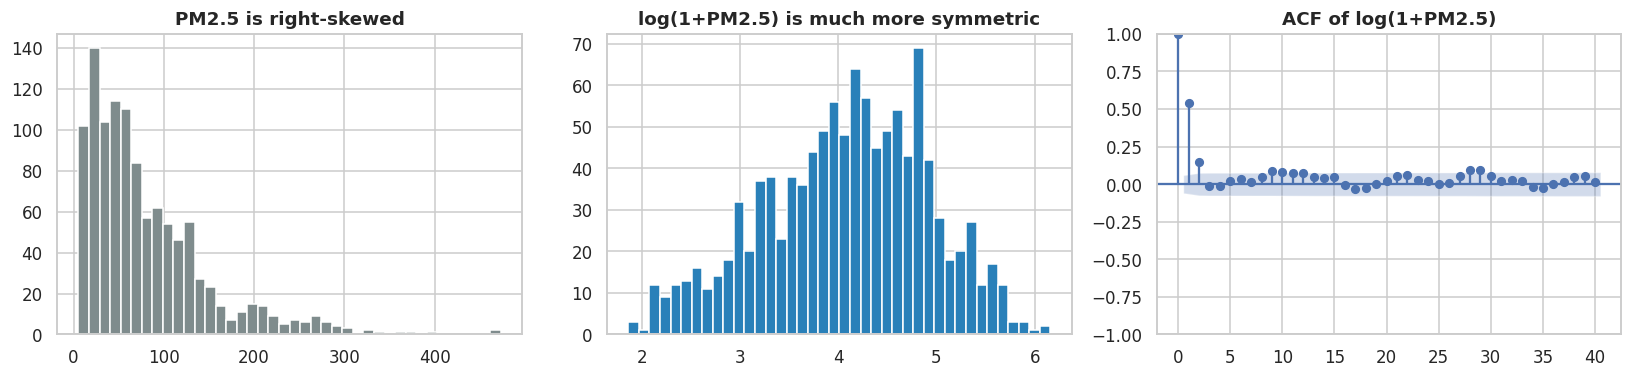

In [16]:
TARGET = "PM25"
TRAIN_END = "2016-02-29"
train_city = city.loc[:TRAIN_END]
log_pm = np.log1p(train_city[TARGET])
adf_raw, adf_log = adfuller(train_city[TARGET])[:2], adfuller(log_pm)[:2]
print(f"ADF PM2.5      : stat = {adf_raw[0]:.2f}, p = {adf_raw[1]:.4f}")
print(f"ADF log1p PM2.5: stat = {adf_log[0]:.2f}, p = {adf_log[1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(train_city[TARGET], bins=40, color="#7f8c8d"); axes[0].set_title("PM2.5 is right-skewed")
axes[1].hist(log_pm, bins=40, color="#2980b9"); axes[1].set_title("log(1+PM2.5) is much more symmetric")
plot_acf(log_pm, lags=40, ax=axes[2], title="ACF of log(1+PM2.5)")
plt.tight_layout(); plt.savefig(OUT_DIR / "04_target_distribution_acf.png", bbox_inches="tight"); plt.show()

Train: 2013-03-01 -> 2016-02-29  (1096 days)
Test : 2016-03-01 -> 2017-02-28  (365 days)


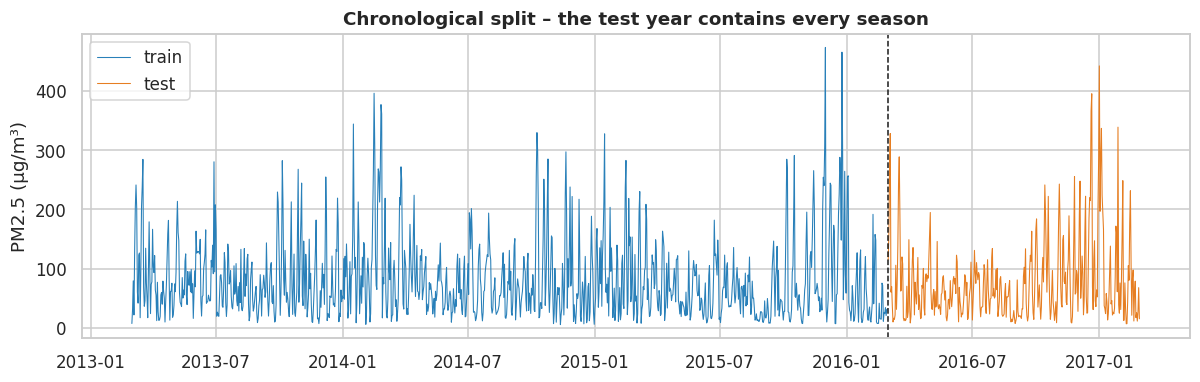

In [17]:
y_all = city[TARGET]
y_train_full, y_test = y_all.loc[:TRAIN_END], y_all.loc[pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1):]
print(f"Train: {y_train_full.index.min().date()} -> {y_train_full.index.max().date()}  ({len(y_train_full)} days)")
print(f"Test : {y_test.index.min().date()} -> {y_test.index.max().date()}  ({len(y_test)} days)")

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(y_train_full, lw=0.7, label="train", color="#2980b9"); ax.plot(y_test, lw=0.7, label="test", color="#e67e22")
ax.axvline(pd.Timestamp(TRAIN_END), color="k", ls="--", lw=1); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Chronological split – the test year contains every season"); ax.legend()
plt.show()

## 4. Feature engineering



In [18]:
SPRING_FESTIVAL = ["2014-01-31", "2015-02-19", "2016-02-08", "2017-01-28"]   # Lunar New Year dates in the sample period
fw_days = pd.DatetimeIndex([d for sf in SPRING_FESTIVAL for d in pd.date_range(pd.Timestamp(sf) - pd.Timedelta(days=2), periods=8)])


def calendar_features(idx):
    f = pd.DataFrame(index=idx)
    doy = idx.dayofyear
    f["doy_sin"], f["doy_cos"] = np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)
    f["month"], f["dow"] = idx.month, idx.dayofweek
    f["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    f["heating_season"] = (((idx.month == 11) & (idx.day >= 15)) | idx.month.isin([12, 1, 2]) |
                           ((idx.month == 3) & (idx.day <= 15))).astype(int)
    f["fireworks_window"] = idx.isin(fw_days).astype(int)
    return f


def build_features(d, target=TARGET):
    """Feature matrix indexed by the TARGET DAY; every lagged feature only uses data up to the previous day."""
    y = d[target]
    f = pd.DataFrame(index=d.index)
    for k in (1, 2, 3, 7, 14):
        f[f"{target}_lag{k}"] = y.shift(k)
    for w in (3, 7, 14, 30):
        f[f"{target}_roll_mean{w}"] = y.shift(1).rolling(w).mean()
    f[f"{target}_roll_std7"] = y.shift(1).rolling(7).std()
    f[f"{target}_diff1"] = y.shift(1) - y.shift(2)
    for c in [p for p in POLLUTANTS if p != target]:
        f[f"{c}_lag1"] = d[c].shift(1)
    for c in ["TEMP", "PRES", "DEWP", "RAIN", "WSPM", "wind_u", "wind_v"]:
        f[f"{c}_lag1"] = d[c].shift(1)
    f["temp_dew_spread_lag1"] = (d["TEMP"] - d["DEWP"]).shift(1)
    f["WSPM_roll3"] = d["WSPM"].shift(1).rolling(3).mean()
    return pd.concat([f, calendar_features(d.index)], axis=1)


X_all = build_features(city)
valid = X_all.dropna().index                      # first 30 days have no 30-day history
X_all, y_all = X_all.loc[valid], city.loc[valid, TARGET]

X_train, y_train = X_all.loc[:TRAIN_END], y_all.loc[:TRAIN_END]
X_test, y_test = X_all.loc[pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1):], y_all.loc[pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1):]
print(f"{X_all.shape[1]} features | train rows: {len(X_train)} | test rows: {len(X_test)}")
print("Features:", ", ".join(X_all.columns))

32 features | train rows: 1066 | test rows: 365
Features: PM25_lag1, PM25_lag2, PM25_lag3, PM25_lag7, PM25_lag14, PM25_roll_mean3, PM25_roll_mean7, PM25_roll_mean14, PM25_roll_mean30, PM25_roll_std7, PM25_diff1, PM10_lag1, SO2_lag1, NO2_lag1, CO_lag1, O3_lag1, TEMP_lag1, PRES_lag1, DEWP_lag1, RAIN_lag1, WSPM_lag1, wind_u_lag1, wind_v_lag1, temp_dew_spread_lag1, WSPM_roll3, doy_sin, doy_cos, month, dow, is_weekend, heating_season, fireworks_window


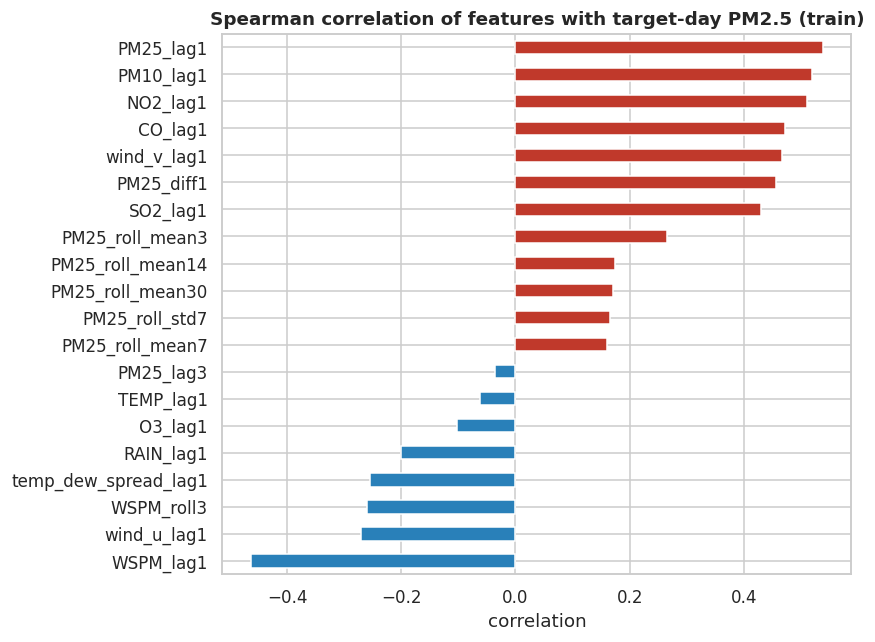

In [19]:
# How informative are the features? (Spearman correlation with next-day PM2.5, TRAINING data only)
corr = X_train.corrwith(y_train, method="spearman").sort_values()
top = pd.concat([corr.head(8), corr.tail(12)])
fig, ax = plt.subplots(figsize=(8, 6))
top.plot.barh(ax=ax, color=np.where(top > 0, "#c0392b", "#2980b9"))
ax.set_title("Spearman correlation of features with target-day PM2.5 (train)"); ax.set_xlabel("correlation")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_feature_correlation.png", bbox_inches="tight"); plt.show()

In [20]:
AQI_BINS = [-np.inf, 35, 75, 115, 150, 250, np.inf]
AQI_LABELS = ["Excellent", "Good", "Light", "Moderate", "Heavy", "Severe"]

def aqi_cat(x):
    return pd.cut(np.asarray(x), bins=AQI_BINS, labels=False)

def evaluate(y_true, y_pred):
    """Regression metrics + AQI-category metrics (PM2.5 only)."""
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    out = {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
           "MAE": mean_absolute_error(y_true, y_pred),
           "R2": r2_score(y_true, y_pred)}
    ct, cp = aqi_cat(y_true), aqi_cat(y_pred)
    out["Cat. acc."] = np.mean(ct == cp)
    out["Within 1 cat."] = np.mean(np.abs(ct - cp) <= 1)
    heavy = ct >= 4                                    # heavily / severely polluted days (> 150 µg/m3)
    out["Heavy-day recall"] = np.mean(cp[heavy] >= 4) if heavy.any() else np.nan
    warned = cp >= 4                                   # days on which a heavy-pollution warning would be issued
    out["Heavy-day precision"] = np.mean(ct[warned] >= 4) if warned.any() else np.nan
    return out

results, preds = {}, {}

def register(name, y_pred):
    preds[name] = pd.Series(np.clip(np.asarray(y_pred, dtype=float), 0, None), index=y_test.index)
    results[name] = evaluate(y_test, preds[name])
    return pd.Series(results[name]).round(3)

print("Test-set category distribution (days):")
print(pd.Series(aqi_cat(y_test)).map(dict(enumerate(AQI_LABELS))).value_counts().reindex(AQI_LABELS).to_string())

Test-set category distribution (days):
Excellent    111
Good         110
Light         73
Moderate      24
Heavy         36
Severe        11


In [21]:
display(pd.DataFrame({"Persistence (y[t-1])": register("Persistence", X_test[f"{TARGET}_lag1"]),
                      "7-day moving average": register("Moving avg 7d", X_test[f"{TARGET}_roll_mean7"])}).T)

,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
Persistence (y[t-1]),63.103,42.950,0.173,0.392,0.773,0.596,0.596
7-day moving average,71.935,52.498,-0.075,0.285,0.677,0.149,0.333


In [22]:
train_idx = y_train_full.index
test_idx = y_test.index

def fourier(idx, K=2):
    doy = idx.dayofyear.values
    return pd.DataFrame({f"{fn.__name__}{k}": fn(2 * np.pi * k * doy / 365.25)
                         for k in range(1, K + 1) for fn in (np.sin, np.cos)}, index=idx)

weather_cols = ["TEMP", "DEWP", "PRES", "WSPM", "wind_u", "wind_v", "RAIN"]
def exog_frame(idx, with_weather):
    e = fourier(idx)
    e["heating_season"] = calendar_features(idx)["heating_season"].values
    if with_weather:
        w = city[weather_cols].shift(1).bfill().loc[idx]          # yesterday's weather only (first day back-filled)
        e = pd.concat([e, w.add_suffix("_lag1")], axis=1)
    return e

endog_all = np.log1p(city[TARGET])
endog_tr, endog_te = endog_all.loc[train_idx], endog_all.loc[test_idx]

def fit_arima(order, with_weather, seasonal_order=(0, 0, 0, 0)):
    ex_tr = exog_frame(train_idx, with_weather)
    mu, sd = ex_tr.mean(), ex_tr.std().replace(0, 1)
    ex_tr = (ex_tr - mu) / sd
    mod = SARIMAX(endog_tr, exog=ex_tr, order=order, seasonal_order=seasonal_order, trend="c",
                  enforce_stationarity=False, enforce_invertibility=False)
    return mod.fit(disp=False, maxiter=200), mu, sd

def one_step_forecast(res, mu, sd, with_weather):
    ex_te = (exog_frame(test_idx, with_weather) - mu) / sd
    app = res.append(endog_te, exog=ex_te, refit=False)             # keep parameters, update the state with each new day
    p = app.get_prediction(start=test_idx[0]).predicted_mean
    return np.expm1(p.loc[test_idx])

# ---- order selection by AIC (training data only)
grid = []
for p in range(4):
    for q in range(3):
        try:
            r, _, _ = fit_arima((p, 0, q), with_weather=False)
            grid.append({"p": p, "q": q, "AIC": r.aic})
        except Exception:
            pass
grid = pd.DataFrame(grid).sort_values("AIC").reset_index(drop=True)
display(grid.head(5).round(1))
best_p, best_q = int(grid.loc[0, "p"]), int(grid.loc[0, "q"])
print(f"Selected order for ARIMA: ({best_p}, 0, {best_q})")

,p,q,AIC
0,0,2,2302.1
1,1,2,2304.1
2,3,1,2305.1
3,2,0,2305.4
4,2,2,2305.8


Selected order for ARIMA: (0, 0, 2)


In [23]:
res_a, mu_a, sd_a = fit_arima((best_p, 0, best_q), with_weather=False)
print("ARIMA (+Fourier):")
display(register("ARIMA + Fourier", one_step_forecast(res_a, mu_a, sd_a, False)).to_frame().T)

res_x, mu_x, sd_x = fit_arima((best_p, 0, best_q), with_weather=True)
print("ARIMAX (+Fourier +lagged weather):")
display(register("ARIMAX + weather", one_step_forecast(res_x, mu_x, sd_x, True)).to_frame().T)

res_s, mu_s, sd_s = fit_arima((best_p, 0, best_q), with_weather=True, seasonal_order=(1, 0, 1, 7))
print("SARIMAX (weekly seasonal (1,0,1,7) + Fourier + weather):")
display(register("SARIMAX (7) + weather", one_step_forecast(res_s, mu_s, sd_s, True)).to_frame().T)

ARIMA (+Fourier):


,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
0,58.465,39.405,0.29,0.356,0.8,0.043,0.667


ARIMAX (+Fourier +lagged weather):


,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
0,55.096,35.72,0.369,0.43,0.849,0.085,0.667


SARIMAX (weekly seasonal (1,0,1,7) + Fourier + weather):


,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
0,55.125,35.699,0.369,0.425,0.847,0.085,0.667


### Regression.

In [25]:
N_CV_SPLITS = 4
RANDOM_STATE = 42
RUN_TUNING = True
RUN_XGBOOST = False

tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
fitted = {}

def tune(estimator, param_dist, n_iter=20, name=""):
    if not RUN_TUNING:
        return estimator.fit(X_train, y_train)
    search = RandomizedSearchCV(estimator, param_dist, n_iter=n_iter, cv=tscv, scoring="neg_root_mean_squared_error",
                                random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    print(f"{name}: best CV-RMSE = {-search.best_score_:.2f}  | params = {search.best_params_}")
    return search.best_estimator_

# ---- Ridge
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30), cv=tscv)).fit(X_train, y_train)
fitted["Ridge"] = ridge
print(f"Ridge: selected alpha = {ridge[-1].alpha_:.2f}")

# ---- Random Forest
rf = tune(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
          {"n_estimators": [200, 300, 500], "max_depth": [4, 6, 8, 12, None], "min_samples_leaf": [2, 5, 10, 20],
           "max_features": [0.3, 0.5, 0.8, 1.0]}, n_iter=15, name="Random Forest")
fitted["Random Forest"] = rf

# ---- Histogram Gradient Boosting
hgb = tune(HistGradientBoostingRegressor(random_state=RANDOM_STATE),
           {"learning_rate": [0.02, 0.03, 0.05, 0.08], "max_iter": [200, 300, 500], "max_depth": [2, 3, 4, 6],
            "min_samples_leaf": [10, 20, 40], "l2_regularization": [0, 1, 5, 10]}, n_iter=20, name="HistGradientBoosting")
fitted["Gradient Boosting"] = hgb

# ---- XGBoost (optional)
if RUN_XGBOOST:
    try:
        from xgboost import XGBRegressor
        xgb = tune(XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
                   {"n_estimators": [200, 400, 600], "learning_rate": [0.02, 0.04, 0.08], "max_depth": [2, 3, 4, 5],
                    "subsample": [0.7, 0.85, 1.0], "colsample_bytree": [0.5, 0.7, 1.0], "reg_lambda": [1, 5, 10]},
                   n_iter=20, name="XGBoost")
        fitted["XGBoost"] = xgb
    except ImportError:
        print("xgboost not installed -> skipped")

Ridge: selected alpha = 62.10
Random Forest: best CV-RMSE = 51.32  | params = {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 8}
HistGradientBoosting: best CV-RMSE = 51.65  | params = {'min_samples_leaf': 40, 'max_iter': 200, 'max_depth': 2, 'learning_rate': 0.03, 'l2_regularization': 10}


In [26]:
rows = {}
for name, model in fitted.items():
    rows[name] = register(name, model.predict(X_test))
display(pd.DataFrame(rows).T)

,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
Ridge,51.356,35.833,0.452,0.419,0.860,0.383,0.692
Random Forest,48.216,33.421,0.517,0.419,0.863,0.574,0.711
Gradient Boosting,48.667,33.759,0.508,0.427,0.868,0.574,0.730


### LSTM

In [28]:
RUN_LSTM = True
if RUN_LSTM:
    import os; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
    import tensorflow as tf
    from sklearn.preprocessing import MinMaxScaler
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    WINDOW = 14
    seq_cols = POLLUTANTS + ["TEMP", "PRES", "DEWP", "RAIN", "WSPM", "wind_u", "wind_v"]
    seq = city[seq_cols].join(calendar_features(city.index)[["doy_sin", "doy_cos", "heating_season"]])
    scaler = MinMaxScaler().fit(seq.loc[:TRAIN_END])                # statistics from the training period only
    S = scaler.transform(seq)
    tgt_col = seq.columns.get_loc(TARGET)

    def make_sequences(dates):
        Xs, ys = [], []
        for d in dates:
            i = city.index.get_loc(d)
            Xs.append(S[i - WINDOW:i]); ys.append(S[i, tgt_col])    # window = days d-14 .. d-1
        return np.array(Xs), np.array(ys)

    Xl_tr, yl_tr = make_sequences(X_train.index); Xl_te, yl_te = make_sequences(X_test.index)
    n_val = 180                                                      # last 180 training days -> early-stopping validation
    lstm = tf.keras.Sequential([tf.keras.layers.Input(shape=Xl_tr.shape[1:]),
                                tf.keras.layers.LSTM(48), tf.keras.layers.Dropout(0.2),
                                tf.keras.layers.Dense(16, activation="relu"), tf.keras.layers.Dense(1)])
    lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    lstm.fit(Xl_tr[:-n_val], yl_tr[:-n_val], validation_data=(Xl_tr[-n_val:], yl_tr[-n_val:]), epochs=100, batch_size=32,
             verbose=0, callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    lo, hi = scaler.data_min_[tgt_col], scaler.data_max_[tgt_col]
    p = lstm.predict(Xl_te, verbose=0).ravel() * (hi - lo) + lo
    display(register("LSTM", p).to_frame().T)
else:
    print("RUN_LSTM = False -> LSTM skipped (set the flag to True to train it).")

,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
0,51.061,34.985,0.458,0.397,0.86,0.34,0.667


## 7. Model comparison and evaluation on the test year

In [29]:
table = pd.DataFrame(results).T
table["Skill vs persistence"] = 1 - table["RMSE"] / table.loc["Persistence", "RMSE"]
table = table.sort_values("RMSE")
table.round(3).to_csv(OUT_DIR / "model_comparison.csv")
display(table.style.format({"RMSE": "{:.1f}", "MAE": "{:.1f}", "R2": "{:.3f}", "Cat. acc.": "{:.1%}",
                            "Within 1 cat.": "{:.1%}", "Heavy-day recall": "{:.1%}", "Heavy-day precision": "{:.1%}",
                            "Skill vs persistence": "{:+.1%}"})
        .background_gradient(subset=["RMSE", "MAE"], cmap="RdYlGn_r").background_gradient(subset=["R2", "Cat. acc."], cmap="RdYlGn"))

best_name = table.drop(index=[i for i in table.index if i in ("Persistence", "Moving avg 7d")]).index[0]
print("Best single model on the test set:", best_name)

,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision,Skill vs persistence
Random Forest,48.2,33.4,0.517,41.9%,86.3%,57.4%,71.1%,+23.6%
Gradient Boosting,48.7,33.8,0.508,42.7%,86.8%,57.4%,73.0%,+22.9%
LSTM,51.1,35.0,0.458,39.7%,86.0%,34.0%,66.7%,+19.1%
Ridge,51.4,35.8,0.452,41.9%,86.0%,38.3%,69.2%,+18.6%
ARIMAX + weather,55.1,35.7,0.369,43.0%,84.9%,8.5%,66.7%,+12.7%
SARIMAX (7) + weather,55.1,35.7,0.369,42.5%,84.7%,8.5%,66.7%,+12.6%
ARIMA + Fourier,58.5,39.4,0.290,35.6%,80.0%,4.3%,66.7%,+7.3%
Persistence,63.1,42.9,0.173,39.2%,77.3%,59.6%,59.6%,+0.0%
Moving avg 7d,71.9,52.5,-0.075,28.5%,67.7%,14.9%,33.3%,-14.0%


Best single model on the test set: Random Forest


In [30]:
from scipy import stats

def diebold_mariano(e_other, e_best, lags=5):
    d = (np.asarray(e_other) ** 2 - np.asarray(e_best) ** 2)
    n, dbar = len(d), d.mean()
    gamma = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(lags + 1)]
    var = (gamma[0] + 2 * sum((1 - k / (lags + 1)) * gamma[k] for k in range(1, lags + 1))) / n
    stat = dbar / np.sqrt(var)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))

dm_rows = {}
for n in table.index:
    if n == best_name:
        continue
    stat, p = diebold_mariano(y_test - preds[n], y_test - preds[best_name])
    dm_rows[n] = {"DM statistic": stat, "p-value": p, f"significantly worse than {best_name} (5 %)": p < 0.05 and stat > 0}
display(pd.DataFrame(dm_rows).T.astype({"DM statistic": float, "p-value": float}).round(3))

,DM statistic,p-value,significantly worse than Random Forest (5 %)
Gradient Boosting,0.721,0.471,False
LSTM,1.589,0.112,False
Ridge,2.398,0.016,True
ARIMAX + weather,2.377,0.017,True
SARIMAX (7) + weather,2.365,0.018,True
ARIMA + Fourier,3.107,0.002,True
Persistence,4.315,0.000,True
Moving avg 7d,5.409,0.000,True


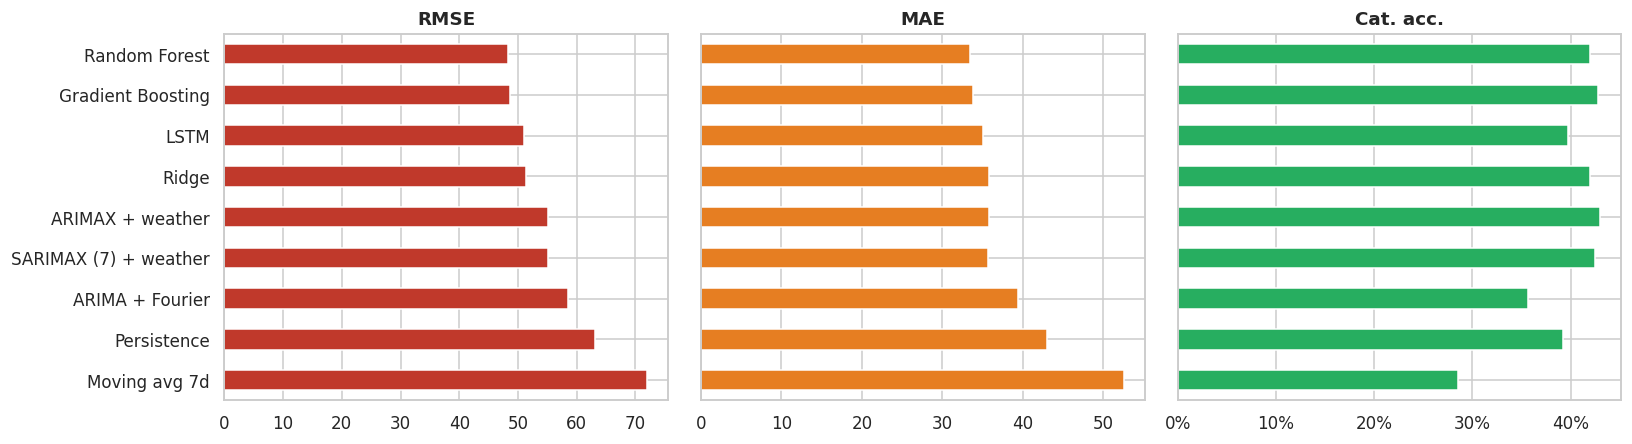

In [31]:
order = table.index

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, color in zip(axes, ["RMSE", "MAE", "Cat. acc."], ["#c0392b", "#e67e22", "#27ae60"]):
    table[col].loc[order].plot.barh(ax=ax, color=color); ax.invert_yaxis(); ax.set_title(col)
    if col == "Cat. acc.": ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_yticklabels([]); axes[2].set_yticklabels([])
plt.tight_layout(); plt.savefig(OUT_DIR / "06_model_comparison.png", bbox_inches="tight"); plt.show()

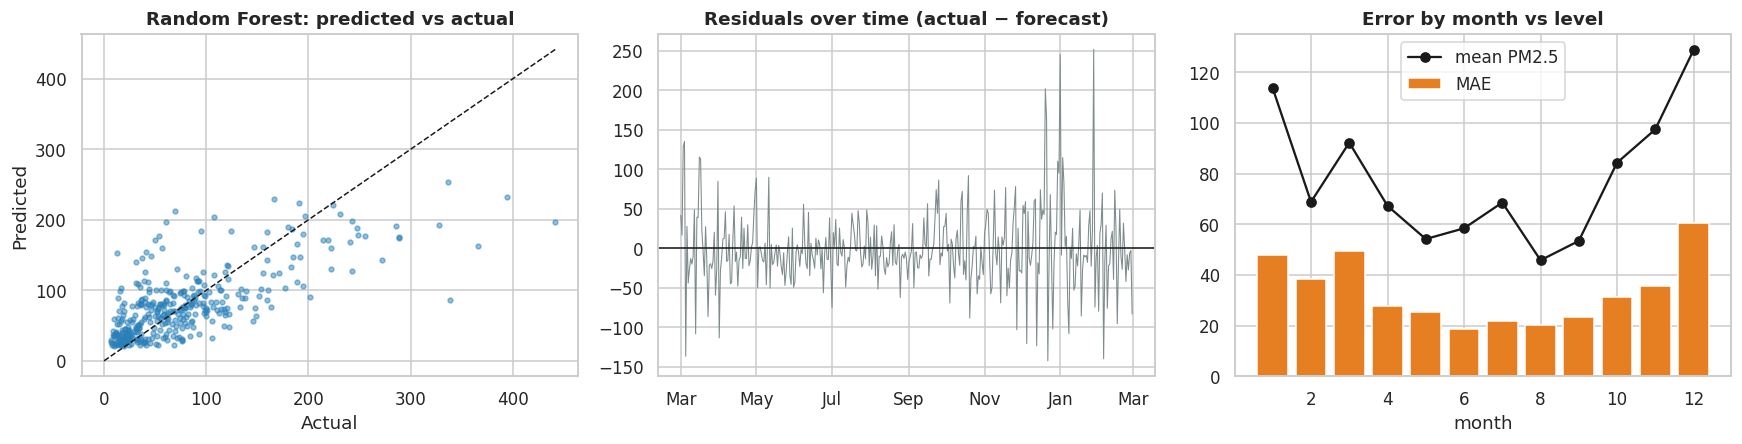

Residual mean (bias): -0.41 µg/m³ | residual std: 48.28 | lag-1 autocorrelation: 0.07


In [32]:
# Diagnostics for the best model: scatter, residuals over time, error by month
res_best = y_test - preds[best_name]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].scatter(y_test, preds[best_name], s=10, alpha=0.5, color="#2980b9")
lim = [0, max(y_test.max(), preds[best_name].max())]; axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title(f"{best_name}: predicted vs actual")

axes[1].plot(res_best, lw=0.7, color="#7f8c8d"); axes[1].axhline(0, color="k", lw=1)
axes[1].set_title("Residuals over time (actual − forecast)"); axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

mae_month = res_best.abs().groupby(res_best.index.month).mean()
mean_month = y_test.groupby(y_test.index.month).mean()
axes[2].bar(mae_month.index, mae_month.values, color="#e67e22", label="MAE")
axes[2].plot(mean_month.index, mean_month.values, "ko-", label="mean PM2.5"); axes[2].legend()
axes[2].set_title("Error by month vs level"); axes[2].set_xlabel("month")
plt.tight_layout(); plt.savefig(OUT_DIR / "09_diagnostics.png", bbox_inches="tight"); plt.show()

print(f"Residual mean (bias): {res_best.mean():+.2f} µg/m³ | residual std: {res_best.std():.2f} | lag-1 autocorrelation: {res_best.autocorr(1):.2f}")

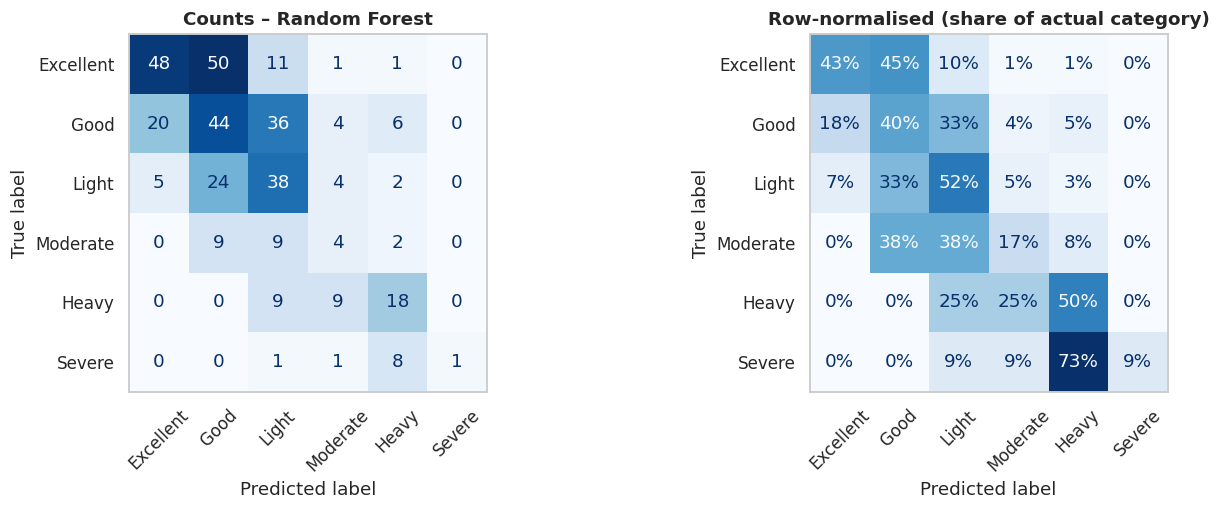

In [33]:
# AQI-category confusion matrix of the best model
ct, cp = aqi_cat(y_test), aqi_cat(preds[best_name])
cm = confusion_matrix(ct, cp, labels=range(6))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ConfusionMatrixDisplay(cm, display_labels=AQI_LABELS).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
axes[0].set_title(f"Counts – {best_name}"); axes[0].grid(False)
ConfusionMatrixDisplay(cm / cm.sum(axis=1, keepdims=True).clip(1), display_labels=AQI_LABELS).plot(
    ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".0%")
axes[1].set_title("Row-normalised (share of actual category)"); axes[1].grid(False)
plt.tight_layout(); plt.savefig(OUT_DIR / "10_confusion_matrix.png", bbox_inches="tight"); plt.show()

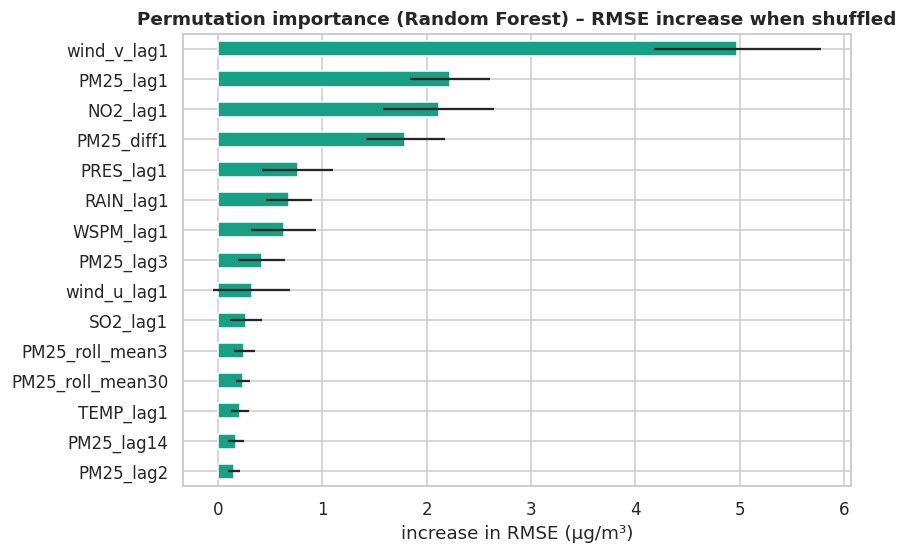

In [34]:
# What drives the forecast?  Permutation importance on the TEST year for the best tree model
tree_models = [n for n in ("Gradient Boosting", "XGBoost", "Random Forest") if n in fitted]
imp_name = best_name if best_name in tree_models else tree_models[0]
pi = permutation_importance(fitted[imp_name], X_test, y_test, scoring="neg_root_mean_squared_error",
                            n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5.2))
imp[::-1].plot.barh(ax=ax, xerr=pd.Series(pi.importances_std, index=X_test.columns)[imp.index][::-1], color="#16a085")
ax.set_title(f"Permutation importance ({imp_name}) – RMSE increase when shuffled"); ax.set_xlabel("increase in RMSE (µg/m³)")
plt.tight_layout(); plt.savefig(OUT_DIR / "11_feature_importance.png", bbox_inches="tight"); plt.show()

In [35]:
pm_station = daily.pivot(index="date", columns="station", values="PM25")
pm_station.index = pd.DatetimeIndex(pm_station.index, freq="D")
outer = ["Huairou", "Changping", "Dingling", "Shunyi"]
urban = [s for s in pm_station.columns if s not in outer]

spatial = pd.DataFrame({"outer_PM25_lag1": pm_station[outer].mean(axis=1).shift(1),
                        "urban_PM25_lag1": pm_station[urban].mean(axis=1).shift(1)})
spatial["urban_minus_outer_lag1"] = spatial["urban_PM25_lag1"] - spatial["outer_PM25_lag1"]
spatial["station_std_lag1"] = pm_station.std(axis=1).shift(1)
spatial["station_max_lag1"] = pm_station.max(axis=1).shift(1)
spatial = spatial.reindex(city.index).interpolate(limit=3)

X_sp_train = X_train.join(spatial).dropna(); X_sp_test = X_test.join(spatial).dropna()
y_sp_train, y_sp_test = y_train.loc[X_sp_train.index], y_test.loc[X_sp_test.index]

base = HistGradientBoostingRegressor(**{k: v for k, v in hgb.get_params().items()}).fit(X_train, y_train)
spat = HistGradientBoostingRegressor(**{k: v for k, v in hgb.get_params().items()}).fit(X_sp_train, y_sp_train)
cmp_sp = pd.DataFrame({"Temporal features only": evaluate(y_test, base.predict(X_test)),
                       "+ spatial features": evaluate(y_sp_test, spat.predict(X_sp_test))}).T
display(cmp_sp.round(3))
register("GB + spatial features", spat.predict(X_sp_test));

,RMSE,MAE,R2,Cat. acc.,Within 1 cat.,Heavy-day recall,Heavy-day precision
Temporal features only,48.667,33.759,0.508,0.427,0.868,0.574,0.73
+ spatial features,48.793,33.715,0.505,0.414,0.871,0.574,0.73
